# SegFormer MAE — Thermal Benchmark Evaluation

Load all 4 benchmark scenes, run two-pass checkerboard inference via the SegFormerMAE inferencer, and evaluate anomaly detection performance (ROC, AUC, Precision/Recall/F1).

### 1. Load all 4 benchmark scenes via LandsatDataBuilder

In [1]:
import os
import sys
import pathlib

import numpy as np
import rasterio
import matplotlib.pyplot as plt

# Ensure project root is on the path
PROJECT_ROOT = str(pathlib.Path(os.getcwd()).parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from app.models.file_processing.sources import FileSourceConfig
from app.utils.dataset_builder.landsat_dataset_builder import LandsatDataBuilder

BENCHMARK_ROOT = os.path.join(PROJECT_ROOT, "benchmarking", "thermal")
DATASET_IDS = [1, 2, 3, 4]

datasets = {}
for did in DATASET_IDS:
    folder = os.path.join(BENCHMARK_ROOT, str(did))
    tif_files = [f for f in os.listdir(folder) if f.endswith(".TIF")]
    assert len(tif_files) == 1, f"Expected 1 TIF in {folder}, found {tif_files}"
    tif_path = os.path.join(folder, tif_files[0])
    gt_path = os.path.join(folder, "gt.tif")

    print(f"=== Loading Dataset {did}: {tif_files[0]} ===")
    builder = LandsatDataBuilder(
        file_source_configuration=FileSourceConfig(source_path=tif_path)
    )
    vendable = builder.vend_dataset()

    # Load ground truth
    with rasterio.open(gt_path) as src:
        gt_data = src.read(1)

    datasets[did] = {
        "name": tif_files[0].replace("_ST_B10.TIF", ""),
        "vendable": vendable,
        "thermal_cube": vendable.normalized_thermal_cube,       # (1, H, W)
        "validity_cube": vendable.validity_cube,                 # (1, H, W)
        "pure_validity": vendable.pure_validity_mask,            # (1, H, W)
        "gt": (gt_data > 0).astype(np.uint8),                   # (H, W)
    }

    thermal = vendable.normalized_thermal_cube.squeeze()
    valid_mask = vendable.pure_validity_mask.squeeze()
    valid_temps = thermal[valid_mask == 1]
    n_anom = datasets[did]["gt"].sum()

    print(f"  Thermal cube shape: {vendable.normalized_thermal_cube.shape}")
    print(f"  Validity mask shape: {vendable.validity_cube.shape}")
    print(f"  Valid pixels: {(valid_mask == 1).sum():,}, Anomaly pixels: {n_anom:,}")
    print(f"  Temp range: [{valid_temps.min():.1f}, {valid_temps.max():.1f}] C")
    print(f"  Mean temp: {valid_temps.mean():.1f} C")
    print()

=== Loading Dataset 1: LC09_L2SP_141045_20250604_20250605_02_T1_ST_B10.TIF ===
Using device: cuda
Max Temp = 80.34671783447266
Min Temp = -124.1500015258789
Masked Array
(40711448, 1)
[ 5.70057964 30.2351265  36.49352264 42.5639267  45.11376953]
Anchors Set to [[-10.        ]
 [  5.        ]
 [ 36.49352264]
 [ 42.5639267 ]
 [ 45.11376953]]
24.49352264404297
[0 1]
  Thermal cube shape: (1, 7681, 7521)
  Validity mask shape: (1, 7681, 7521)
  Valid pixels: 40,711,448, Anomaly pixels: 6,636
  Temp range: [-21.2, 80.3] C
  Mean temp: 35.6 C

=== Loading Dataset 2: LC08_L2SP_138045_20250215_20250226_02_T1_ST_B10.TIF ===
Using device: cuda
Max Temp = 67.39926147460938
Min Temp = -124.1500015258789
Masked Array
(40533402, 1)
[24.09978104 24.76287651 25.82246399 30.30690575 32.36455536]
Anchors Set to [[-10.        ]
 [  5.        ]
 [ 25.82246399]
 [ 30.30690575]
 [ 32.36455536]]
13.822463989257812
[0 1]
  Thermal cube shape: (1, 7721, 7571)
  Validity mask shape: (1, 7721, 7571)
  Valid pixe

### 2. Thermal Scenes Overview (2x2)

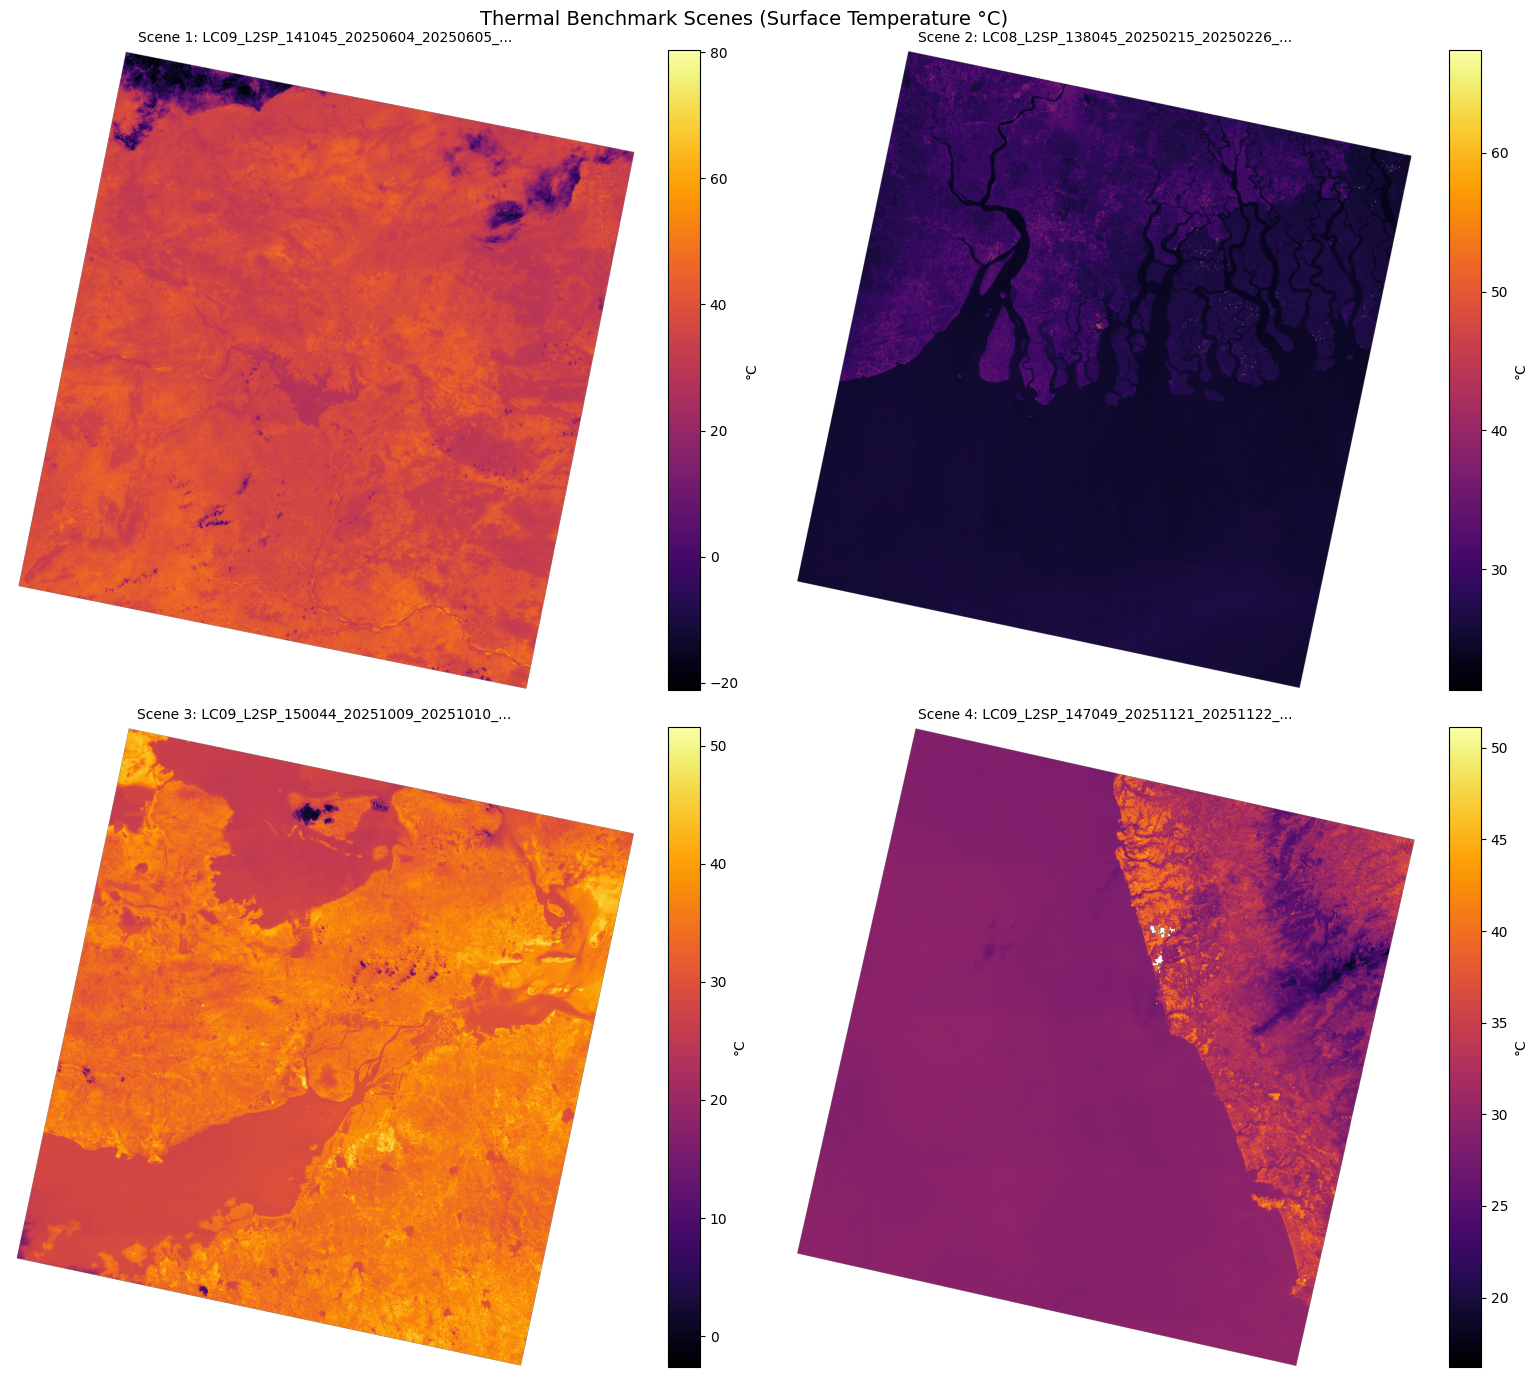

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for idx, did in enumerate(DATASET_IDS):
    d = datasets[did]
    thermal = d["thermal_cube"].squeeze()           # (H, W)
    validity = d["pure_validity"].squeeze()          # (H, W)
    temp_display = np.ma.masked_where(validity == 0, thermal)

    im = axes[idx].imshow(temp_display, cmap="inferno")
    axes[idx].set_title(f"Scene {did}: {d['name'][:35]}...", fontsize=10)
    axes[idx].axis("off")
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04, label="°C")

plt.suptitle("Thermal Benchmark Scenes (Surface Temperature °C)", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

### 3. Anomaly Overlay — Cyan Dots on Thermal Scenes (2x2)

Ground truth anomaly pixels overlaid as prominent cyan dots on each thermal scene.

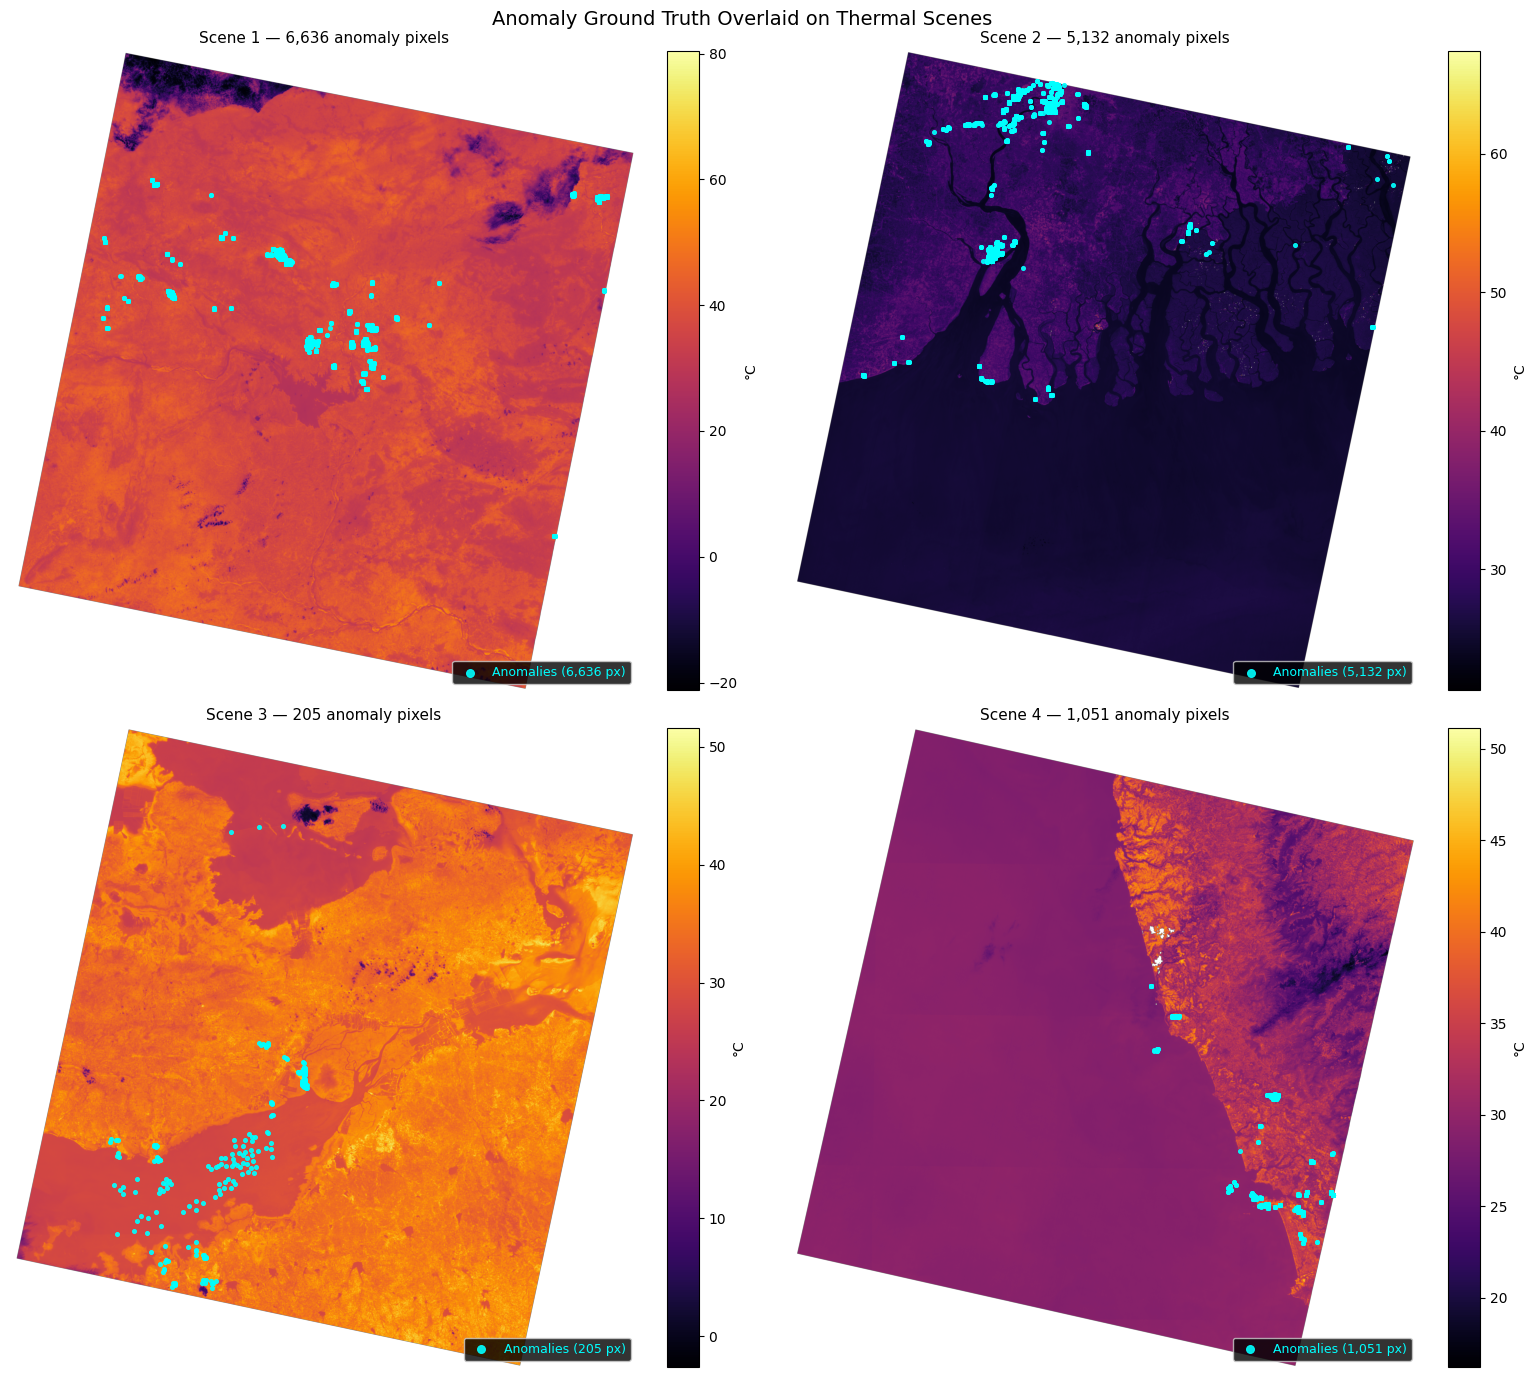

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for idx, did in enumerate(DATASET_IDS):
    d = datasets[did]
    thermal = d["thermal_cube"].squeeze()
    validity = d["pure_validity"].squeeze()
    temp_display = np.ma.masked_where(validity == 0, thermal)

    im = axes[idx].imshow(temp_display, cmap="inferno")

    # Overlay anomaly pixels as prominent cyan dots
    anom_rows, anom_cols = np.where(d["gt"] > 0)
    axes[idx].scatter(
        anom_cols, anom_rows,
        c="cyan", s=8, marker="o", linewidths=0.8, edgecolors="cyan", alpha=0.9,
        label=f"Anomalies ({len(anom_rows):,} px)",
    )

    axes[idx].set_title(f"Scene {did} — {len(anom_rows):,} anomaly pixels", fontsize=11)
    axes[idx].axis("off")
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04, label="°C")
    axes[idx].legend(loc="lower right", fontsize=9, markerscale=2,
                     framealpha=0.8, facecolor="black", labelcolor="cyan")

plt.suptitle("Anomaly Ground Truth Overlaid on Thermal Scenes", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

### 4. Zoomed Anomaly Regions (2x2)

Zoom into the bounding box of anomaly pixels (with 200px padding) for each scene.

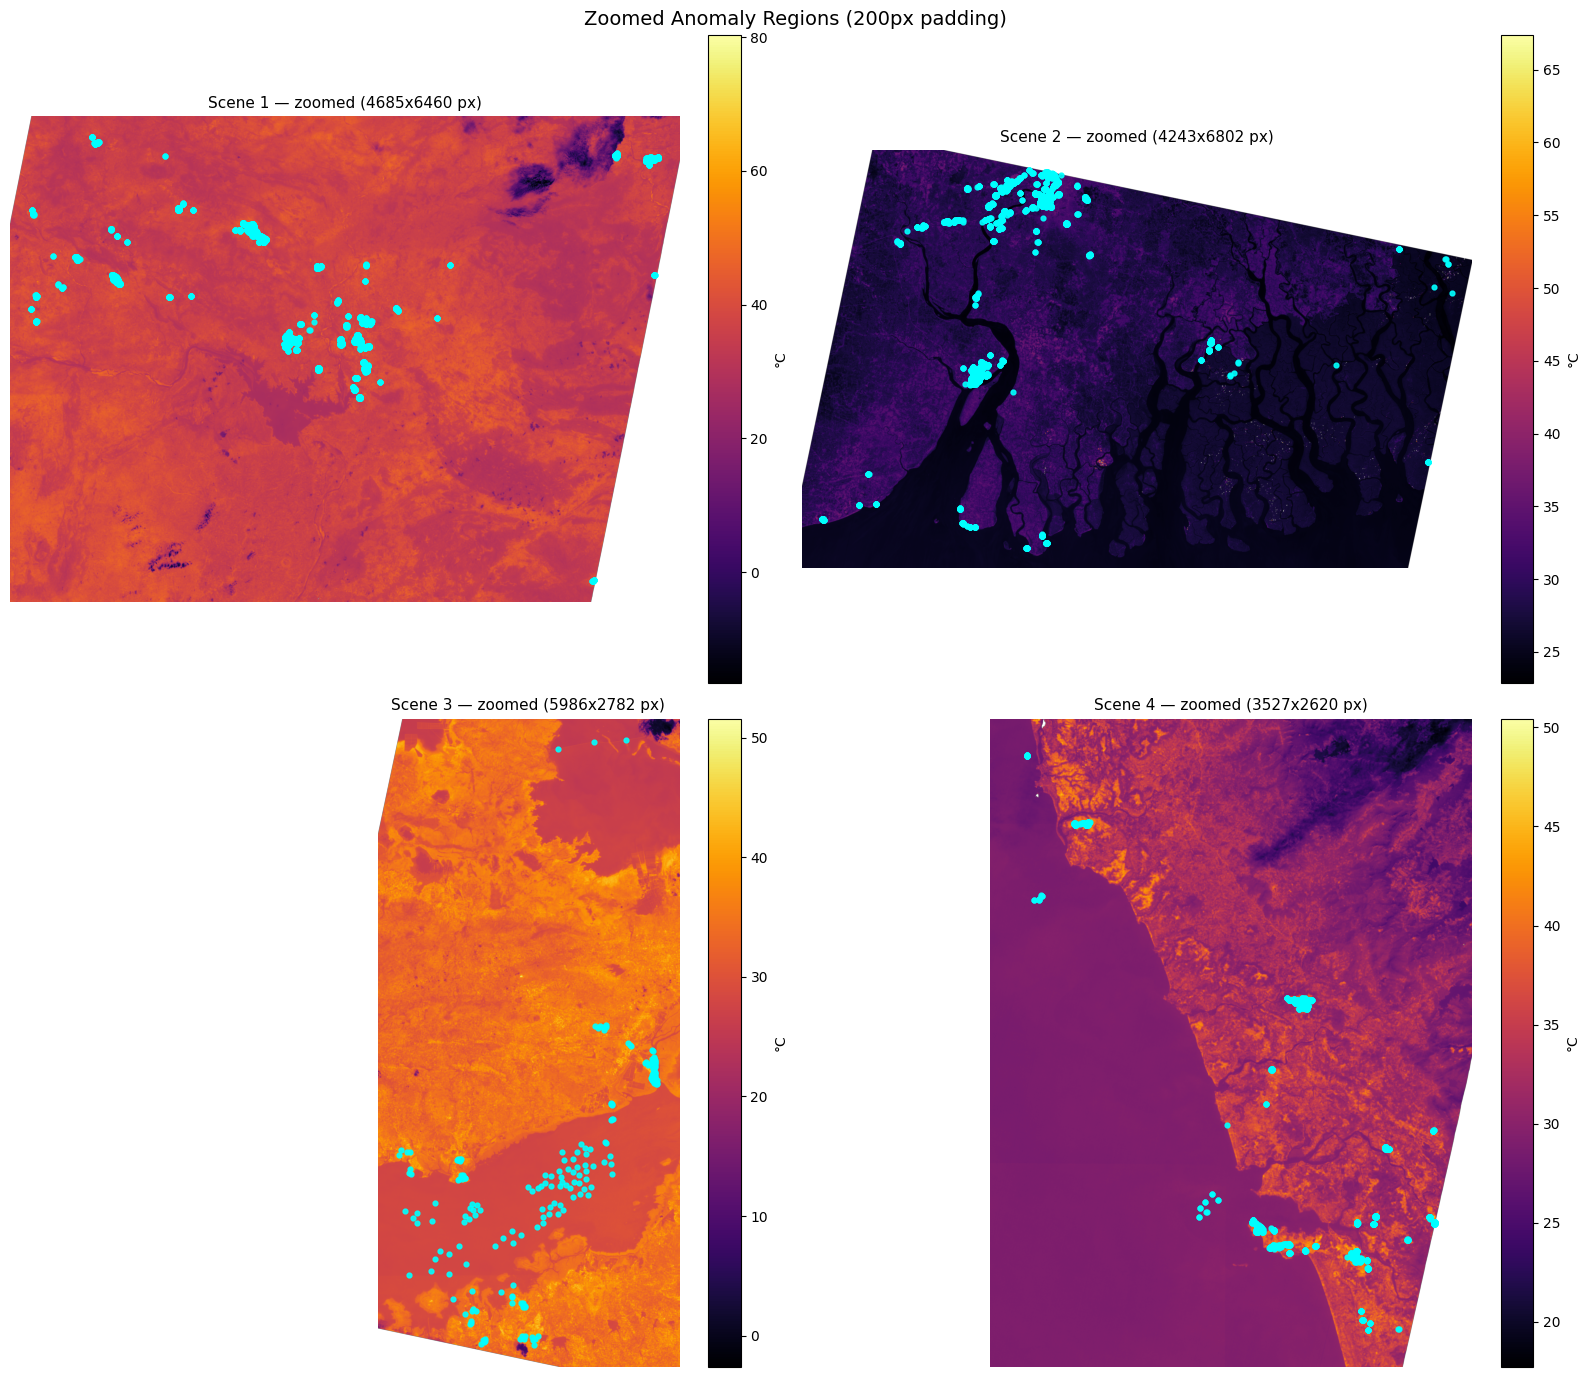

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

PAD = 200  # pixels of padding around anomaly bounding box

for idx, did in enumerate(DATASET_IDS):
    d = datasets[did]
    thermal = d["thermal_cube"].squeeze()
    validity = d["pure_validity"].squeeze()
    gt = d["gt"]
    H, W = thermal.shape

    anom_rows, anom_cols = np.where(gt > 0)
    r_min = max(0, anom_rows.min() - PAD)
    r_max = min(H, anom_rows.max() + PAD)
    c_min = max(0, anom_cols.min() - PAD)
    c_max = min(W, anom_cols.max() + PAD)

    crop_temp = thermal[r_min:r_max, c_min:c_max]
    crop_valid = validity[r_min:r_max, c_min:c_max]
    crop_gt = gt[r_min:r_max, c_min:c_max]

    temp_display = np.ma.masked_where(crop_valid == 0, crop_temp)
    im = axes[idx].imshow(temp_display, cmap="inferno")

    ar, ac = np.where(crop_gt > 0)
    axes[idx].scatter(ac, ar, c="cyan", s=12, marker="o",
                      linewidths=1.0, edgecolors="cyan", alpha=0.9)

    axes[idx].set_title(
        f"Scene {did} — zoomed ({r_max-r_min}x{c_max-c_min} px)", fontsize=11
    )
    axes[idx].axis("off")
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04, label="°C")

plt.suptitle("Zoomed Anomaly Regions (200px padding)", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

### 5. Anomaly Temperature Histograms

For each scene: overlay the temperature distribution of anomaly pixels (red) on top of the full scene distribution (blue).

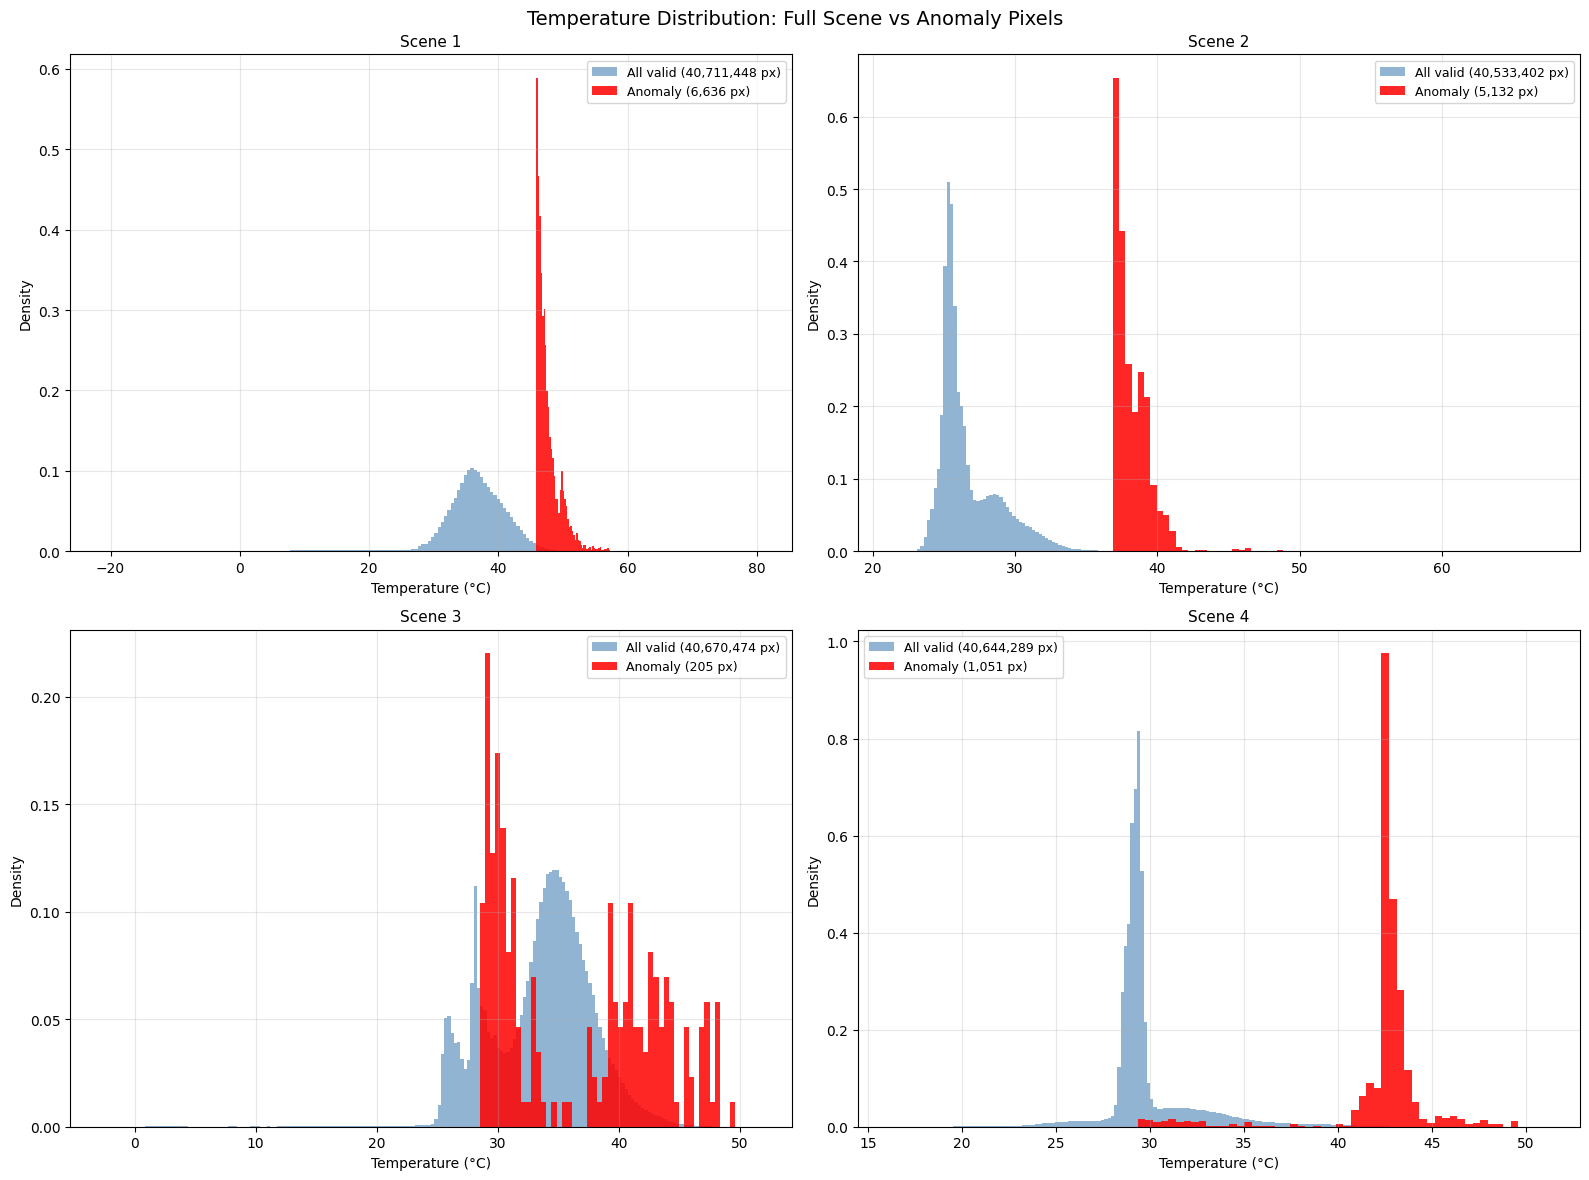

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, did in enumerate(DATASET_IDS):
    d = datasets[did]
    thermal = d["thermal_cube"].squeeze()
    validity = d["pure_validity"].squeeze()
    gt = d["gt"]

    valid_temps = thermal[validity == 1]
    anomaly_temps = thermal[(gt > 0) & (validity == 1)]

    axes[idx].hist(valid_temps, bins=200, density=True, alpha=0.6,
                   color="steelblue", label=f"All valid ({len(valid_temps):,} px)")
    axes[idx].hist(anomaly_temps, bins=50, density=True, alpha=0.85,
                   color="red", label=f"Anomaly ({len(anomaly_temps):,} px)")
    axes[idx].set_xlabel("Temperature (°C)")
    axes[idx].set_ylabel("Density")
    axes[idx].set_title(f"Scene {did}", fontsize=11)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle("Temperature Distribution: Full Scene vs Anomaly Pixels", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

### 6. Anomaly Z-Score Analysis

Z-scores of anomaly pixel temperatures relative to the scene distribution, and percentile ranking.

Scene 1: anomaly z-score mean=1.52, std=0.23, below -2s: 0, above +2s: 280
Scene 2: anomaly z-score mean=5.42, std=0.61, below -2s: 0, above +2s: 5132
Scene 3: anomaly z-score mean=0.72, std=1.50, below -2s: 0, above +2s: 54
Scene 4: anomaly z-score mean=5.23, std=1.20, below -2s: 0, above +2s: 999


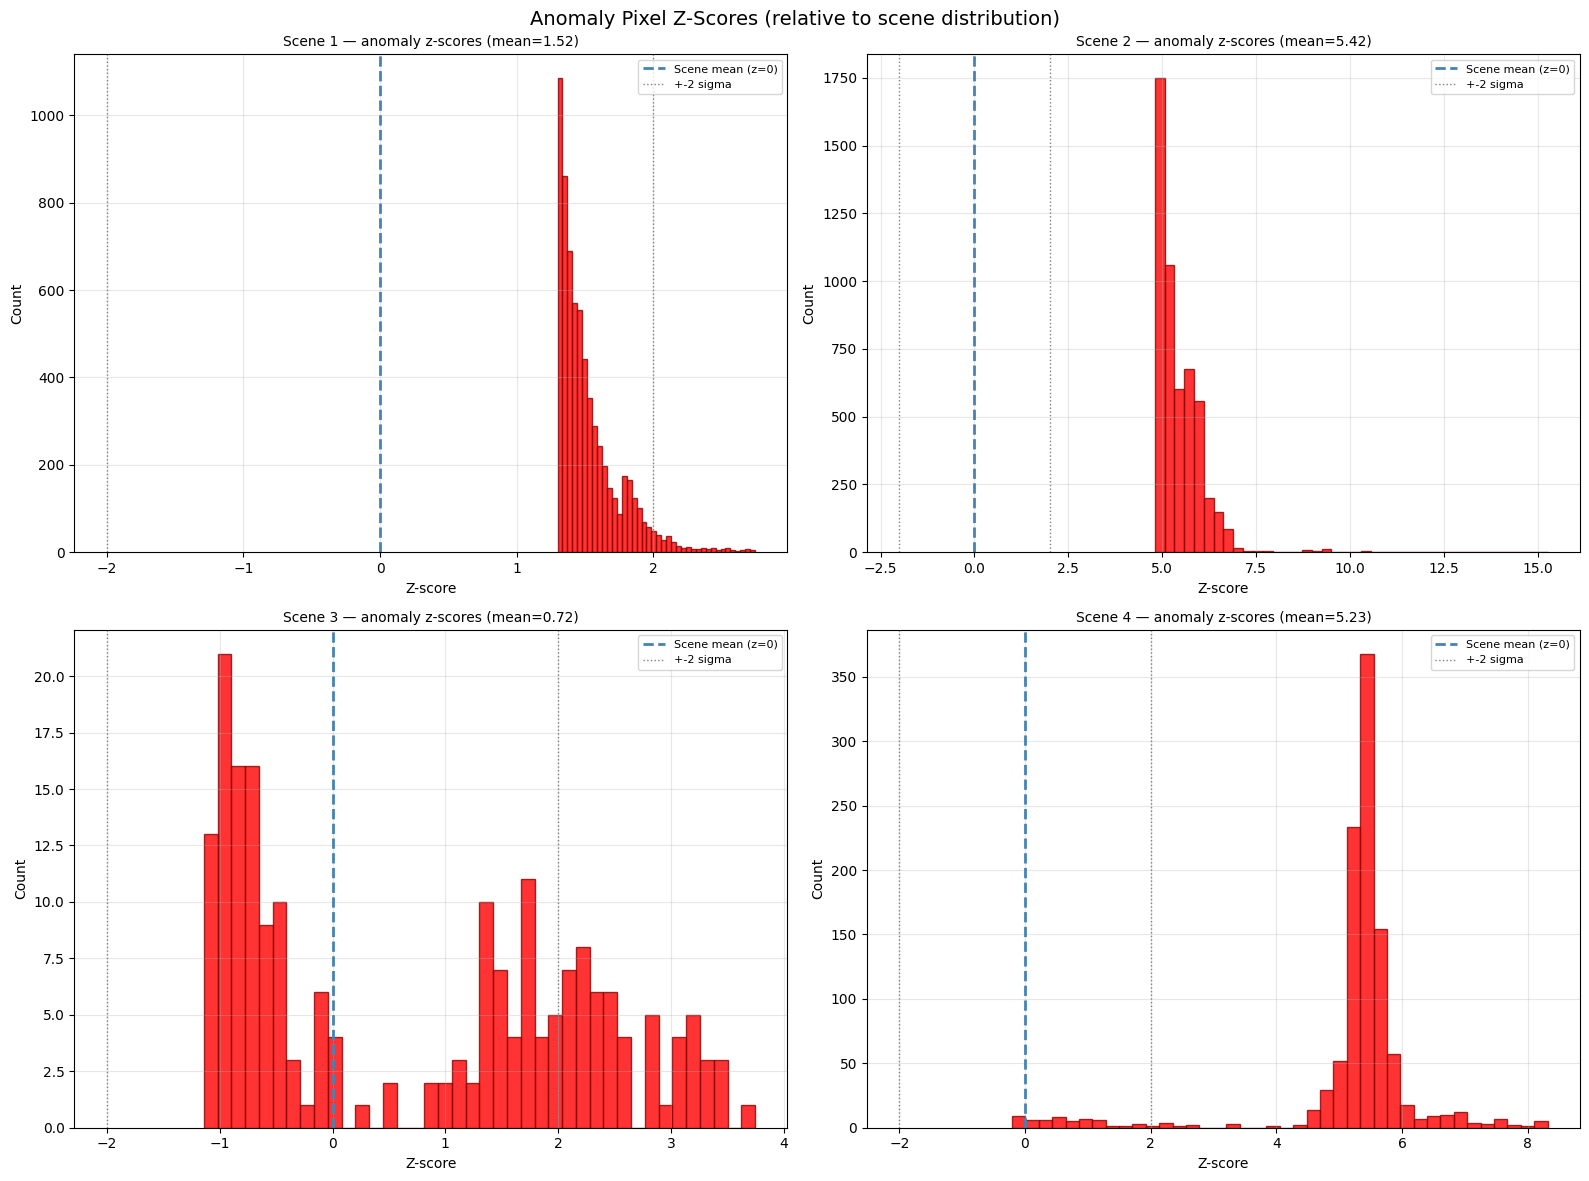

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, did in enumerate(DATASET_IDS):
    d = datasets[did]
    thermal = d["thermal_cube"].squeeze()
    validity = d["pure_validity"].squeeze()
    gt = d["gt"]

    valid_temps = thermal[validity == 1]
    anomaly_temps = thermal[(gt > 0) & (validity == 1)]

    scene_mean = valid_temps.mean()
    scene_std = valid_temps.std()
    anomaly_zscores = (anomaly_temps - scene_mean) / scene_std

    axes[idx].hist(anomaly_zscores, bins=40, alpha=0.8, color="red", edgecolor="darkred")
    axes[idx].axvline(0, color="steelblue", lw=2, linestyle="--", label="Scene mean (z=0)")
    axes[idx].axvline(-2, color="gray", lw=1, linestyle=":", label="+-2 sigma")
    axes[idx].axvline(2, color="gray", lw=1, linestyle=":")
    axes[idx].set_xlabel("Z-score")
    axes[idx].set_ylabel("Count")
    axes[idx].set_title(f"Scene {did} — anomaly z-scores (mean={anomaly_zscores.mean():.2f})", fontsize=10)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

    print(f"Scene {did}: anomaly z-score mean={anomaly_zscores.mean():.2f}, "
          f"std={anomaly_zscores.std():.2f}, "
          f"below -2s: {(anomaly_zscores < -2).sum()}, "
          f"above +2s: {(anomaly_zscores > 2).sum()}")

plt.suptitle("Anomaly Pixel Z-Scores (relative to scene distribution)", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

### 7. Summary Statistics Table

In [7]:
print(f"{'':=<100}")
print(f"{'THERMAL BENCHMARK DATASET SUMMARY':^100}")
print(f"{'':=<100}")

for did in DATASET_IDS:
    d = datasets[did]
    thermal = d["thermal_cube"].squeeze()
    validity = d["pure_validity"].squeeze()
    gt = d["gt"]
    H, W = thermal.shape

    valid_temps = thermal[validity == 1]
    anomaly_temps = thermal[(gt > 0) & (validity == 1)]
    anom_rows, anom_cols = np.where(gt > 0)

    scene_mean = valid_temps.mean()
    scene_std = valid_temps.std()

    print(f"\n--- Dataset {did}: {d['name']} ---")
    print(f"  Image dimensions:      {H} x {W} pixels")
    print(f"  Total pixels:          {H * W:,}")
    print(f"  Valid pixels:          {(validity == 1).sum():,} ({(validity == 1).sum() / (H * W) * 100:.1f}%)")
    print(f"  Anomaly pixels:        {gt.sum():,} ({gt.sum() / (validity == 1).sum() * 100:.4f}% of valid)")
    print(f"  Scene temp (C):        mean={scene_mean:.2f}, std={scene_std:.2f}")
    print(f"                         min={valid_temps.min():.2f}, max={valid_temps.max():.2f}")
    print(f"                         P1={np.percentile(valid_temps, 1):.2f}, P99={np.percentile(valid_temps, 99):.2f}")
    if len(anomaly_temps) > 0:
        print(f"  Anomaly temp (C):      mean={anomaly_temps.mean():.2f}, std={anomaly_temps.std():.2f}")
        print(f"                         min={anomaly_temps.min():.2f}, max={anomaly_temps.max():.2f}")
        anom_zscores = (anomaly_temps - scene_mean) / scene_std
        print(f"  Anomaly z-score:       mean={anom_zscores.mean():.2f}, std={anom_zscores.std():.2f}")
        print(f"  Anomaly bbox (row):    [{anom_rows.min()}, {anom_rows.max()}]")
        print(f"  Anomaly bbox (col):    [{anom_cols.min()}, {anom_cols.max()}]")
        print(f"  Anomaly bbox size:     {anom_rows.max()-anom_rows.min()+1} x {anom_cols.max()-anom_cols.min()+1} px")

                                 THERMAL BENCHMARK DATASET SUMMARY                                  

--- Dataset 1: LC09_L2SP_141045_20250604_20250605_02_T1 ---
  Image dimensions:      7681 x 7521 pixels
  Total pixels:          57,768,801
  Valid pixels:          40,711,448 (70.5%)
  Anomaly pixels:        6,636 (0.0163% of valid)
  Scene temp (C):        mean=35.57, std=7.91
                         min=-21.19, max=80.35
                         P1=-6.70, P99=46.16
  Anomaly temp (C):      mean=47.62, std=1.79
                         min=45.85, max=57.30
  Anomaly z-score:       mean=1.52, std=0.23
  Anomaly bbox (row):    [1547, 5832]
  Anomaly bbox (col):    [1095, 7155]
  Anomaly bbox size:     4286 x 6061 px

--- Dataset 2: LC08_L2SP_138045_20250215_20250226_02_T1 ---
  Image dimensions:      7721 x 7571 pixels
  Total pixels:          58,455,691
  Valid pixels:          40,533,402 (69.3%)
  Anomaly pixels:        5,132 (0.0127% of valid)
  Scene temp (C):        mean=26.68, s

---
# Part 2 — Model Inference & Benchmarking

Load a checkpointed spatial autoencoder model and run full-scene reconstruction on all 4 benchmark datasets.
Produces: anomaly detection maps, original vs reconstruction, residual MSE maps, ROC curves, and precision/recall/F1 statistics.

### 8. Initialize the Inferencer

In [26]:
import torch
from app.models.training.inference_config import InferenceConfig
from app.foundation_models.inferencers.inferencer_factory import get_inferencer

PATCH_SIZE = 256

CHECKPOINT = os.path.join(
    "/home/user57/checkpoints/segformer_mae_v1/segformer_mae_v0.3.0_epoch448.pt",  # UPDATE epoch as needed
)

config = InferenceConfig(
    foundation_model_name="segformer_mae",
    model_config={
        "model_type": "segformer_mae",
        "in_channels": 1,
        "embed_dims": [16,32,64,96],
        "num_heads": [1, 2, 4, 8],
        "reduction_ratios": [8, 4, 2, 1],
        "num_blocks": [1, 1, 1, 1],
        "decoder_dim": 96,
        "expansion_ratio": 2,
        "drop_rate": 0.0,
        "mask_ratio": 0.5,
    },
    checkpoint_path=CHECKPOINT,
    patch_size=PATCH_SIZE,
    stride=64,
    masking_strategy="random",
    checkerboard_cell_size=1,
    pixel_stats_path=os.path.join(
        PROJECT_ROOT, "app/constants/thermal_pixel_consts.json"
    ),
    inference_batch_size=128,
    erosion_kernel_size=7
)

inferencer = get_inferencer(config)

### 9. Run Full-Scene Reconstruction on All 4 Datasets

In [27]:
# Residual type: "mse" = (orig - recon)^2, "l1" = |orig - recon|
RESIDUAL_TYPE = "mse"  # change to "l1" to experiment

def compute_residual(original, recon, mask):
    diff = original - recon
    if RESIDUAL_TYPE == "l1":
        return np.abs(diff) * mask
    return diff ** 2 * mask

from app.foundation_models.components.token_masking import TokenMasking

for did in DATASET_IDS:
    d = datasets[did]
    print(f"=== Reconstructing Dataset {did} ===")

    scene_tensor = torch.from_numpy(d["thermal_cube"]).float()   # (1, H, W)
    mask_tensor = torch.from_numpy(d["validity_cube"]).float()   # (1, H, W)

    reconstruction = inferencer.predict_full_scene(scene_tensor, mask_tensor).cpu()  # (1, H, W)

    # Erode the validity mask to match what the inferencer used for accumulation.
    # Border pixels (within kernel_size//2 of invalid regions) have zero reconstruction
    # because the inferencer excluded them. Using the original mask would compute
    # residual = (original_temp - 0)^2 at those positions, creating huge false outliers.
    eroded_mask = TokenMasking.erode_mask(mask_tensor.unsqueeze(0), kernel_size=7).squeeze(0)

    original = scene_tensor.squeeze().cpu().numpy()       # (H, W)
    recon = reconstruction.squeeze().cpu().numpy()        # (H, W)
    mask = eroded_mask.squeeze().cpu().numpy()             # (H, W) -- eroded
    residual = compute_residual(original, recon, mask)

    d["original"] = original
    d["recon"] = recon
    d["mask"] = mask
    d["residual"] = residual

    valid_residuals = residual[mask == 1]
    print(f"  Residual type: {RESIDUAL_TYPE}")
    print(f"  Original range: [{(original * mask).min():.2f}, {(original * mask).max():.2f}]")
    print(f"  Recon range:    [{(recon * mask).min():.2f}, {(recon * mask).max():.2f}]")
    print(f"  Residual (valid): mean={valid_residuals.mean():.4f}, "
          f"median={np.median(valid_residuals):.4f}, max={valid_residuals.max():.4f}")
    print()

=== Reconstructing Dataset 1 ===
  Residual type: mse
  Original range: [-0.00, 46.72]
  Recon range:    [-0.00, 62.64]
  Residual (valid): mean=0.2397, median=0.0651, max=1272.4663

=== Reconstructing Dataset 2 ===
  Residual type: mse
  Original range: [-0.00, 67.40]
  Recon range:    [-0.00, 56.99]
  Residual (valid): mean=0.0787, median=0.0131, max=1153.0416

=== Reconstructing Dataset 3 ===
  Residual type: mse
  Original range: [-0.00, 43.21]
  Recon range:    [-0.00, 53.21]
  Residual (valid): mean=0.1634, median=0.0292, max=180.9198

=== Reconstructing Dataset 4 ===
  Residual type: mse
  Original range: [-0.00, 51.13]
  Recon range:    [-0.00, 48.48]
  Residual (valid): mean=0.0546, median=0.0023, max=280.8812



### 10. Original vs Reconstruction (2x2)

Side-by-side original and reconstruction for each scene, each on its own color scale.

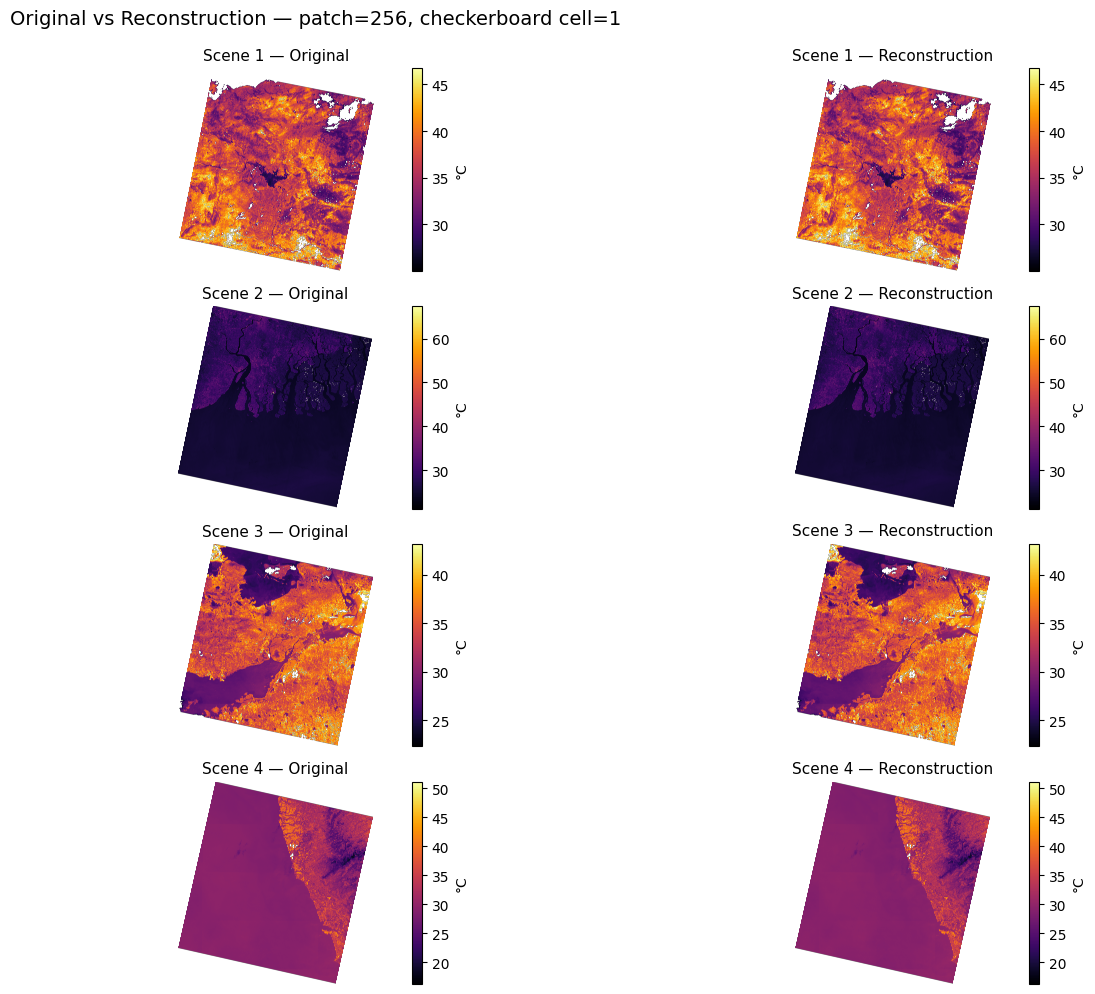

In [28]:
fig, axes = plt.subplots(4, 2, figsize=(16, 10))

for idx, did in enumerate(DATASET_IDS):
    d = datasets[did]
    original_masked = np.ma.masked_where(d["mask"] == 0, d["original"])
    recon_masked = np.ma.masked_where(d["mask"] == 0, d["recon"])
    vmax, vmin = original_masked.max(), original_masked.min()

    im0 = axes[idx, 0].imshow(original_masked, cmap="inferno")
    axes[idx, 0].set_title(f"Scene {did} — Original", fontsize=11)
    axes[idx, 0].axis("off")
    plt.colorbar(im0, ax=axes[idx, 0], fraction=0.046, pad=0.04, label="°C")

    im1 = axes[idx, 1].imshow(recon_masked, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[idx, 1].set_title(f"Scene {did} — Reconstruction", fontsize=11)
    axes[idx, 1].axis("off")
    plt.colorbar(im1, ax=axes[idx, 1], fraction=0.046, pad=0.04, label="°C")

plt.suptitle(
    f"Original vs Reconstruction — patch={PATCH_SIZE}, "
    f"checkerboard cell={config.checkerboard_cell_size}",
    fontsize=14, y=0.99,
)
plt.tight_layout()
plt.show()

### 11. Residual MSE Maps — Clipped at 99.5th Percentile (2x2)

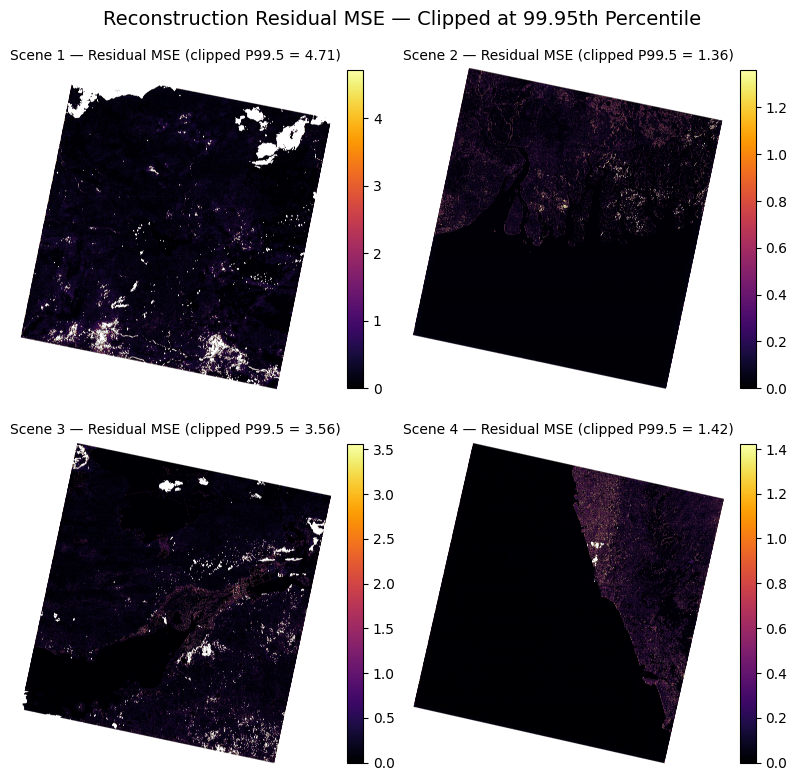

In [29]:
CLIP_PERCENTILE = 99.5

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.ravel()

for idx, did in enumerate(DATASET_IDS):
    d = datasets[did]
    residual = d["residual"]
    mask = d["mask"]

    valid_residuals = residual[mask == 1]
    clip_val = np.percentile(valid_residuals, CLIP_PERCENTILE)

    residual_masked = np.ma.masked_where(mask == 0, residual)
    im = axes[idx].imshow(residual_masked, cmap="inferno", vmin=0, vmax=clip_val)
    axes[idx].set_title(
        f"Scene {did} — Residual MSE (clipped P{CLIP_PERCENTILE} = {clip_val:.2f})",
        fontsize=10,
    )
    axes[idx].axis("off")
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

plt.suptitle("Reconstruction Residual MSE — Clipped at 99.95th Percentile", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

### 12. Detected vs Actual Anomaly Maps (2x2)

Green dots = detected anomalies (above best-F1 threshold), Cyan dots = ground truth anomalies, overlaid on the original thermal scene.

In [30]:
from sklearn.metrics import roc_curve, auc

# First, compute per-dataset best-F1 thresholds and store results
PERCENTILE_RANGE = np.arange(80, 100.0, 1)

for did in DATASET_IDS:
    d = datasets[did]
    residual = d["residual"]
    mask = d["mask"]
    gt = d["gt"]

    valid_mask_flat = mask.astype(bool).ravel()
    scores = residual.ravel()[valid_mask_flat]
    gt_labels = gt.ravel()[valid_mask_flat].astype(int)

    # ROC
    fpr, tpr, roc_thresholds = roc_curve(gt_labels, scores)
    roc_auc = auc(fpr, tpr)

    # Precision / Recall / F1 sweep
    precisions = []
    recalls = []
    f1_scores = []
    thresholds_at_pct = []

    for p in PERCENTILE_RANGE:
        thresh = np.percentile(scores, p)
        predicted = (scores > thresh).astype(int)
        tp = ((predicted == 1) & (gt_labels == 1)).sum()
        fp = ((predicted == 1) & (gt_labels == 0)).sum()
        fn = ((predicted == 0) & (gt_labels == 1)).sum()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)
        thresholds_at_pct.append(thresh)

    precisions = np.array(precisions)
    recalls = np.array(recalls)
    f1_scores = np.array(f1_scores)
    thresholds_at_pct = np.array(thresholds_at_pct)

    best_idx = np.argmax(f1_scores)
    best_pct = PERCENTILE_RANGE[best_idx]
    best_thresh = thresholds_at_pct[best_idx]

    d["fpr"] = fpr
    d["tpr"] = tpr
    d["roc_auc"] = roc_auc
    d["precisions"] = precisions
    d["recalls"] = recalls
    d["f1_scores"] = f1_scores
    d["best_idx"] = best_idx
    d["best_pct"] = best_pct
    d["best_thresh"] = best_thresh
    d["best_f1"] = f1_scores[best_idx]
    d["best_precision"] = precisions[best_idx]
    d["best_recall"] = recalls[best_idx]
    d["scores"] = scores
    d["gt_labels"] = gt_labels

    # Build detected anomaly binary at best-F1 threshold
    # Modifying so that detections are at P99.95
    p9995_thresh = np.percentile(scores, 99.95)
    d["detected_binary"] = ((residual > p9995_thresh) & (mask == 1)).astype(np.uint8)

    detected_count = d["detected_binary"].sum()
    print(f"Dataset {did}: AUC={roc_auc:.4f}, Best F1={f1_scores[best_idx]:.4f} "
          f"@ P{best_pct:.0f} (thresh={best_thresh:.4f}), "
          f"Prec={precisions[best_idx]:.4f}, Rec={recalls[best_idx]:.4f}, "
          f"Detected={detected_count:,} px")

Dataset 1: AUC=0.6485, Best F1=0.0005 @ P99 (thresh=2.4528), Prec=0.0002, Rec=0.1536, Detected=18,974 px
Dataset 2: AUC=0.7728, Best F1=0.0028 @ P99 (thresh=0.8580), Prec=0.0014, Rec=0.1125, Detected=20,204 px
Dataset 3: AUC=0.6626, Best F1=0.0001 @ P99 (thresh=2.1351), Prec=0.0000, Rec=0.0738, Detected=19,838 px
Dataset 4: AUC=0.8782, Best F1=0.0009 @ P99 (thresh=0.9388), Prec=0.0004, Rec=0.1738, Detected=20,272 px


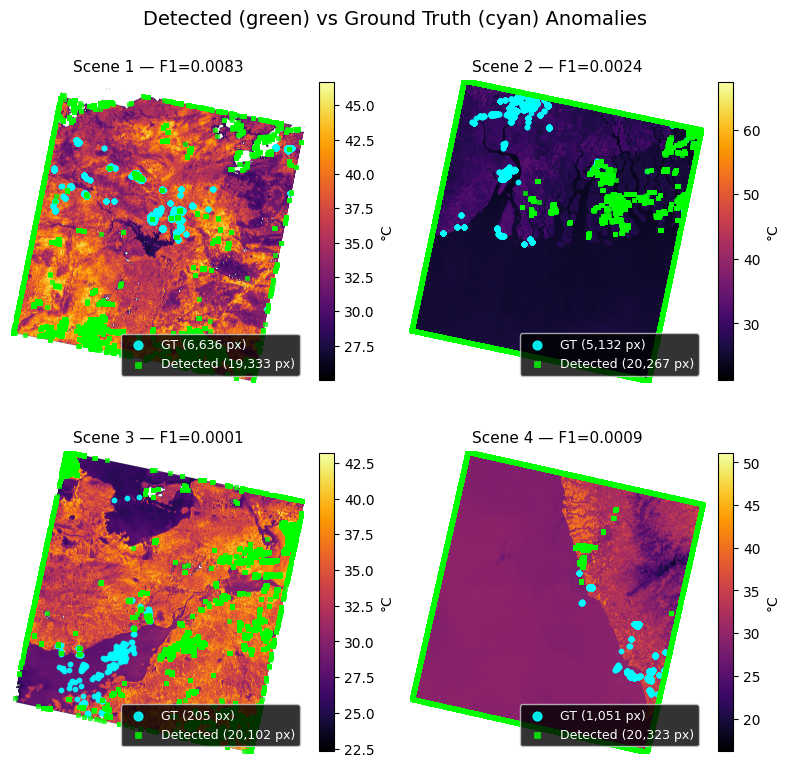

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.ravel()

for idx, did in enumerate(DATASET_IDS):
    d = datasets[did]
    original_masked = np.ma.masked_where(d["mask"] == 0, d["original"])
    im = axes[idx].imshow(original_masked, cmap="inferno")

    # Ground truth anomalies — cyan dots
    gt_rows, gt_cols = np.where(d["gt"] > 0)
    axes[idx].scatter(
        gt_cols, gt_rows,
        c="cyan", s=10, marker="o", linewidths=1.0, edgecolors="cyan", alpha=0.9,
        label=f"GT ({len(gt_rows):,} px)",
    )

    # Detected anomalies — green dots
    det_rows, det_cols = np.where(d["detected_binary"] > 0)
    axes[idx].scatter(
        det_cols, det_rows,
        c="lime", s=6, marker="s", linewidths=0.5, edgecolors="lime", alpha=0.8,
        label=f"Detected ({len(det_rows):,} px)",
    )

    axes[idx].set_title(
        f"Scene {did} — F1={d['best_f1']:.4f}",
        fontsize=11,
    )
    axes[idx].axis("off")
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04, label="°C")
    axes[idx].legend(
        loc="lower right", fontsize=9, markerscale=2,
        framealpha=0.8, facecolor="black", labelcolor="white",
    )

plt.suptitle(
    "Detected (green) vs Ground Truth (cyan) Anomalies",
    fontsize=14, y=0.98,
)
plt.tight_layout()
plt.show()

### 13. ROC Curves (2x2)

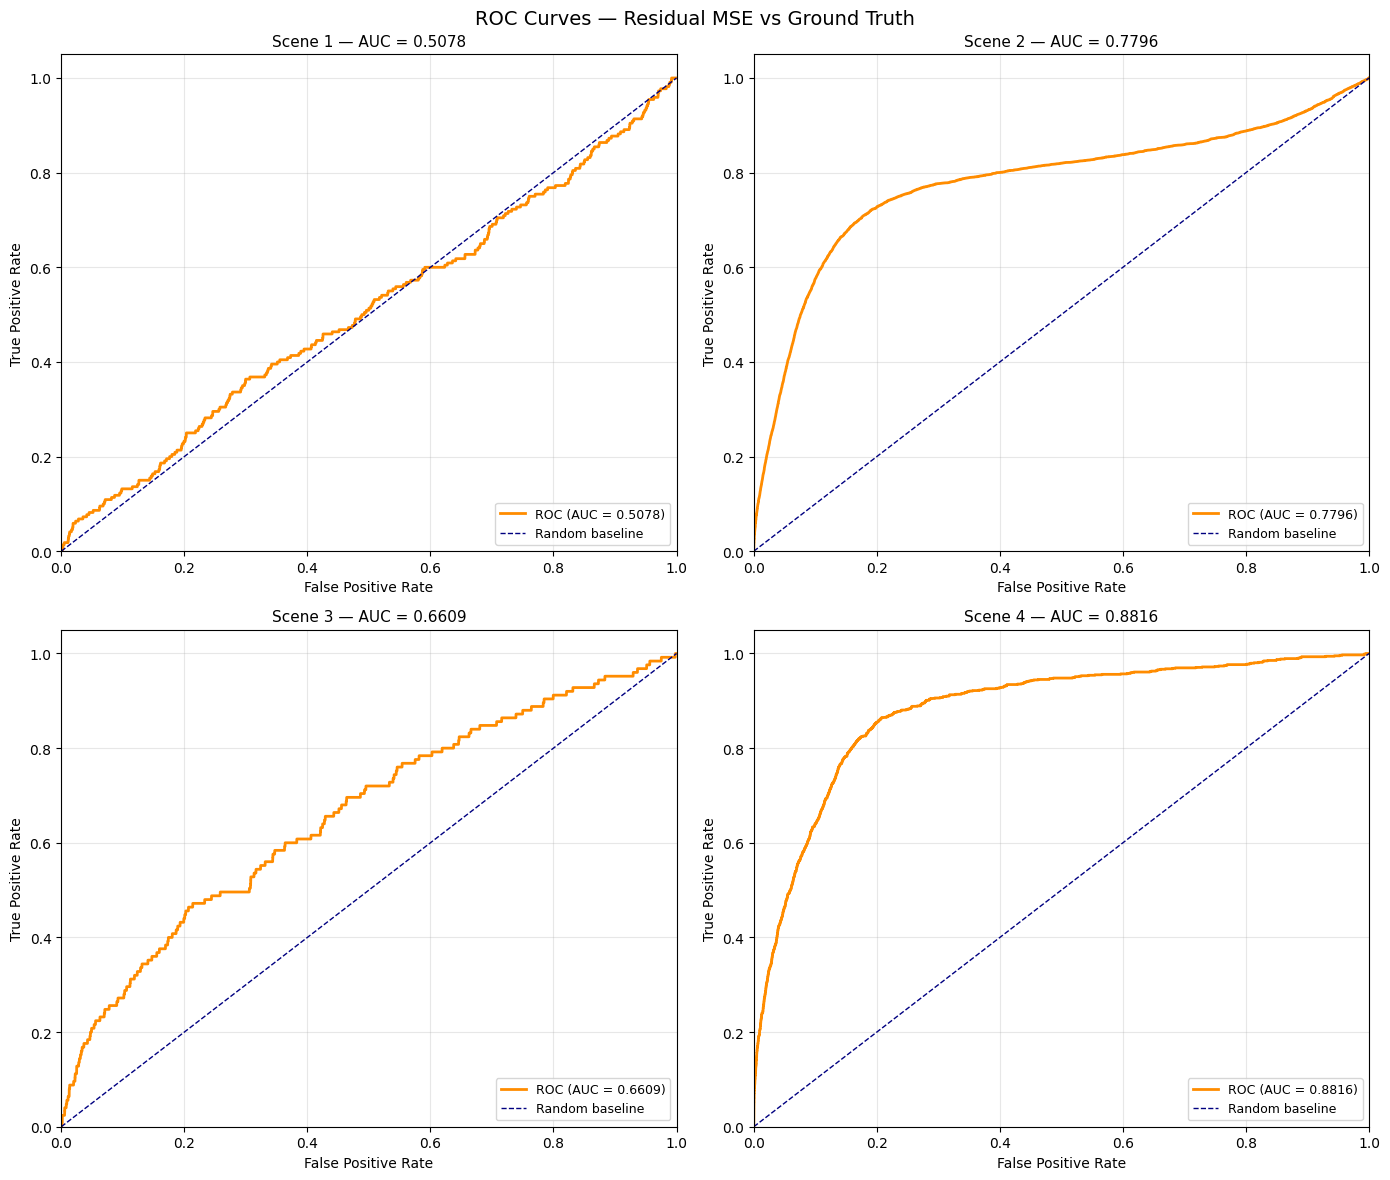

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, did in enumerate(DATASET_IDS):
    d = datasets[did]
    axes[idx].plot(d["fpr"], d["tpr"], color="darkorange", lw=2,
                   label=f"ROC (AUC = {d['roc_auc']:.4f})")
    axes[idx].plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--",
                   label="Random baseline")
    axes[idx].set_xlim([0.0, 1.0])
    axes[idx].set_ylim([0.0, 1.05])
    axes[idx].set_xlabel("False Positive Rate")
    axes[idx].set_ylabel("True Positive Rate")
    axes[idx].set_title(f"Scene {did} — AUC = {d['roc_auc']:.4f}", fontsize=11)
    axes[idx].legend(loc="lower right", fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle("ROC Curves — Residual MSE vs Ground Truth", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

### 14. Precision, Recall & F1 vs Percentile Threshold (2x2)

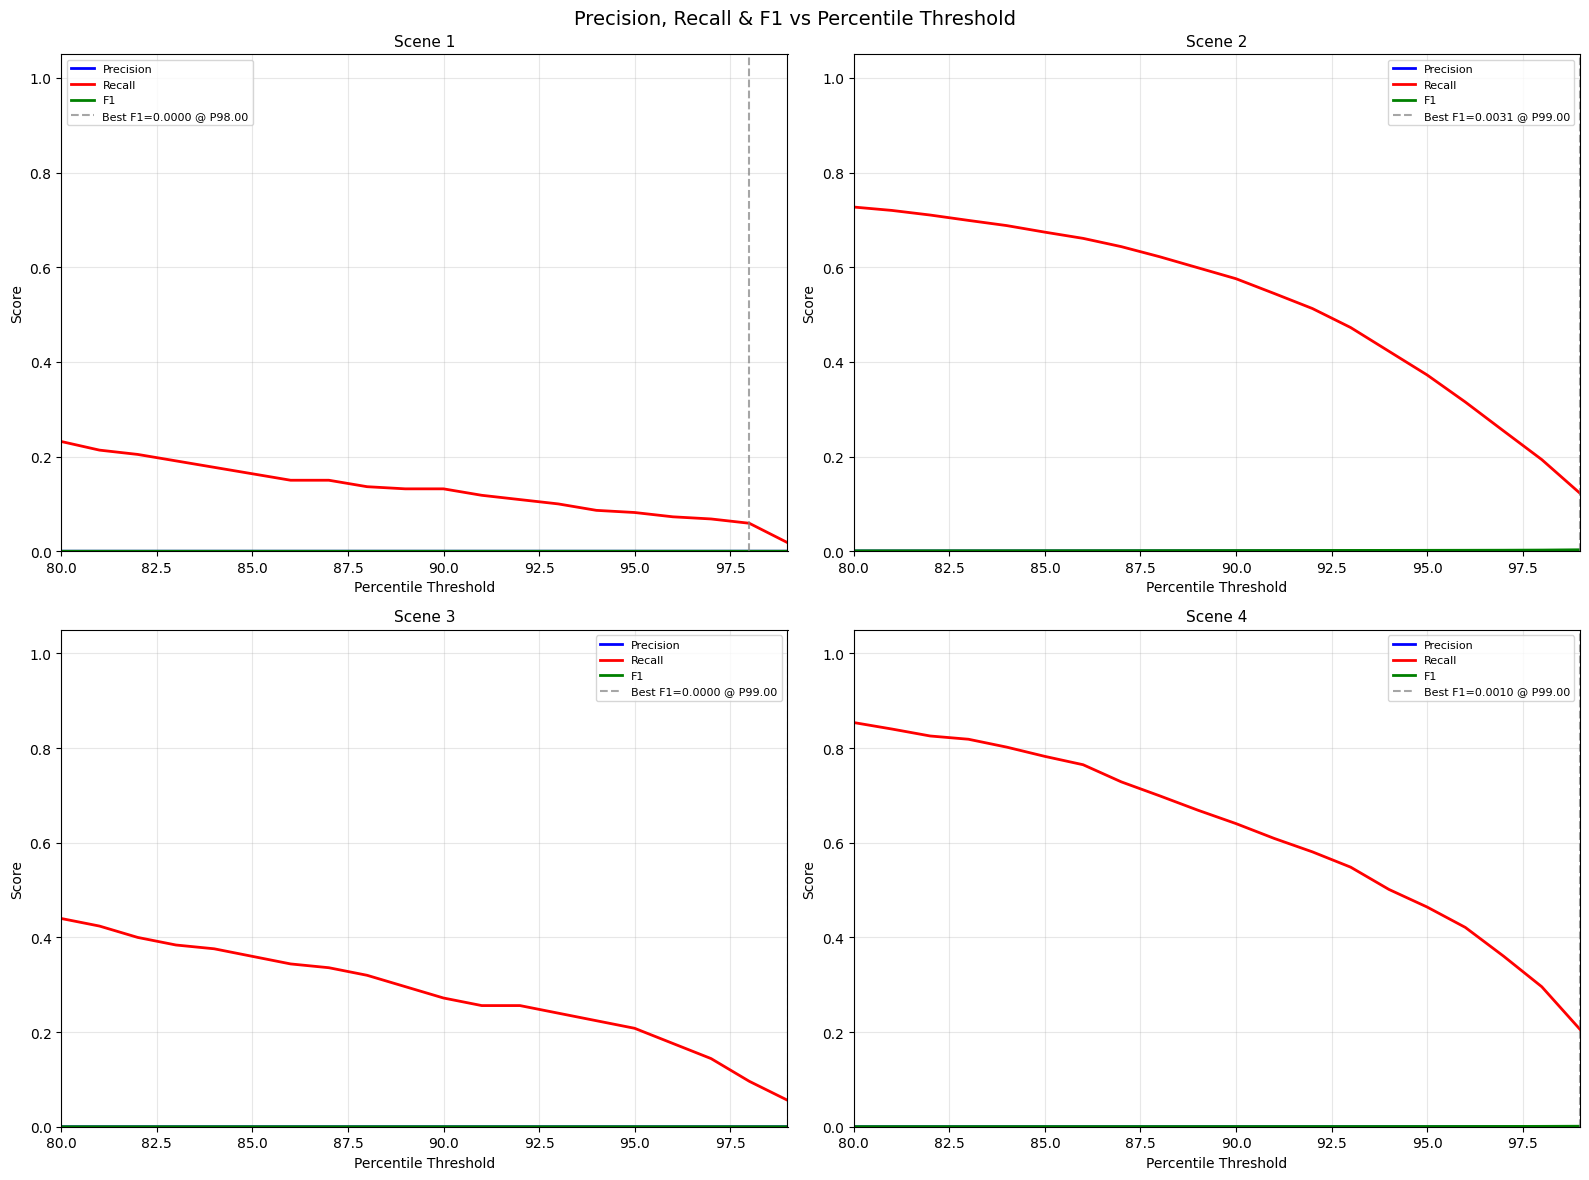

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, did in enumerate(DATASET_IDS):
    d = datasets[did]
    axes[idx].plot(PERCENTILE_RANGE, d["precisions"], color="blue", lw=2, label="Precision")
    axes[idx].plot(PERCENTILE_RANGE, d["recalls"], color="red", lw=2, label="Recall")
    axes[idx].plot(PERCENTILE_RANGE, d["f1_scores"], color="green", lw=2, label="F1")
    axes[idx].axvline(d["best_pct"], color="gray", linestyle="--", alpha=0.7,
                      label=f"Best F1={d['best_f1']:.4f} @ P{d['best_pct']:.2f}")
    axes[idx].set_xlabel("Percentile Threshold")
    axes[idx].set_ylabel("Score")
    axes[idx].set_title(f"Scene {did}", fontsize=11)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([PERCENTILE_RANGE[0], PERCENTILE_RANGE[-1]])
    axes[idx].set_ylim([0.0, 1.05])

plt.suptitle("Precision, Recall & F1 vs Percentile Threshold", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

### 15. Full Numerical Statistics Summary

In [17]:
print(f"{'':=<110}")
print(f"{'MODEL BENCHMARK RESULTS':^110}")
print(f"{'':=<110}")
print(f"Checkpoint: {CHECKPOINT}")
print(f"Patch size: {PATCH_SIZE}, Checkerboard cell: {config.checkerboard_cell_size}")
print(f"Stride: {config.stride or PATCH_SIZE // 2}")
print()

# Header
print(f"{'Metric':<30} {'Scene 1':>15} {'Scene 2':>15} {'Scene 3':>15} {'Scene 4':>15}")
print(f"{'-'*90}")

# Collect stats rows
rows = []
for label, key_fn in [
    ("AUC-ROC", lambda d: f"{d['roc_auc']:.4f}"),
    ("Best F1", lambda d: f"{d['best_f1']:.4f}"),
    ("Best Precision", lambda d: f"{d['best_precision']:.4f}"),
    ("Best Recall", lambda d: f"{d['best_recall']:.4f}"),
    ("Best Percentile", lambda d: f"P{d['best_pct']:.0f}"),
    ("Best Threshold (MSE)", lambda d: f"{d['best_thresh']:.4f}"),
    ("GT Anomaly Pixels", lambda d: f"{d['gt'].sum():,}"),
    ("Detected Pixels (@ best)", lambda d: f"{d['detected_binary'].sum():,}"),
    ("Valid Pixels", lambda d: f"{(d['mask'] == 1).sum():,}"),
    ("Mean Residual MSE", lambda d: f"{d['residual'][d['mask'] == 1].mean():.4f}"),
    ("Median Residual MSE", lambda d: f"{np.median(d['residual'][d['mask'] == 1]):.4f}"),
    ("P99.5 Residual MSE", lambda d: f"{np.percentile(d['residual'][d['mask'] == 1], 99.5):.4f}"),
    ("Max Residual MSE", lambda d: f"{d['residual'][d['mask'] == 1].max():.4f}"),
]:
    vals = [key_fn(datasets[did]) for did in DATASET_IDS]
    print(f"{label:<30} {vals[0]:>15} {vals[1]:>15} {vals[2]:>15} {vals[3]:>15}")

print()

# Per-dataset detailed breakdown
for did in DATASET_IDS:
    d = datasets[did]
    gt_labels = d["gt_labels"]
    scores = d["scores"]
    best_thresh = d["best_thresh"]

    predicted = (scores > best_thresh).astype(int)
    tp = ((predicted == 1) & (gt_labels == 1)).sum()
    fp = ((predicted == 1) & (gt_labels == 0)).sum()
    fn = ((predicted == 0) & (gt_labels == 1)).sum()
    tn = ((predicted == 0) & (gt_labels == 0)).sum()

    print(f"--- Scene {did}: Confusion Matrix @ best F1 threshold ---")
    print(f"  TP={tp:,}  FP={fp:,}")
    print(f"  FN={fn:,}  TN={tn:,}")
    print(f"  Sensitivity (TPR): {tp/(tp+fn):.4f}" if (tp+fn) > 0 else "  Sensitivity: N/A")
    print(f"  Specificity (TNR): {tn/(tn+fp):.4f}" if (tn+fp) > 0 else "  Specificity: N/A")
    print(f"  False Positive Rate: {fp/(fp+tn):.6f}" if (fp+tn) > 0 else "  FPR: N/A")
    print()

                                           MODEL BENCHMARK RESULTS                                            
Checkpoint: /home/user57/checkpoints/segformer_mae_v1/segformer_mae_v0.3.0_epoch448.pt
Patch size: 256, Checkerboard cell: 1
Stride: 64

Metric                                 Scene 1         Scene 2         Scene 3         Scene 4
------------------------------------------------------------------------------------------
AUC-ROC                                 0.5078          0.7796          0.6609          0.8816
Best F1                                 0.0000          0.0031          0.0000          0.0010
Best Precision                          0.0000          0.0016          0.0000          0.0005
Best Recall                             0.0591          0.1224          0.0560          0.2057
Best Percentile                            P98             P99             P99             P99
Best Threshold (MSE)                    0.8974          0.7453          1.2746          0.8

### 16. Top-K Precision & Recall (K = 10,000)

Instead of sweeping percentile thresholds, pick the top 10,000 pixels by residual MSE as detected anomalies and measure precision/recall against ground truth.

In [18]:
TOP_K = 500000

print(f"{'':=<90}")
print(f"{'TOP-K DETECTION (K = ' + f'{TOP_K:,}' + ')':^90}")
print(f"{'':=<90}")
print()
print(f"{'Metric':<30} {'Scene 1':>12} {'Scene 2':>12} {'Scene 3':>12} {'Scene 4':>12}")
print(f"{'-'*78}")

for did in DATASET_IDS:
    d = datasets[did]
    scores = d["scores"]
    gt_labels = d["gt_labels"]

    # Top-K by descending residual MSE
    k = min(TOP_K, len(scores))
    top_k_indices = np.argpartition(scores, -k)[-k:]
    predicted = np.zeros_like(gt_labels)
    predicted[top_k_indices] = 1

    tp = ((predicted == 1) & (gt_labels == 1)).sum()
    fp = ((predicted == 1) & (gt_labels == 0)).sum()
    fn = ((predicted == 0) & (gt_labels == 1)).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    # Threshold at the K-th highest score
    threshold_at_k = np.partition(scores, -k)[-k]

    d["topk_precision"] = precision
    d["topk_recall"] = recall
    d["topk_f1"] = f1
    d["topk_tp"] = tp
    d["topk_fp"] = fp
    d["topk_fn"] = fn
    d["topk_thresh"] = threshold_at_k

# Print table
for label, key in [
    ("Precision", "topk_precision"),
    ("Recall", "topk_recall"),
    ("F1", "topk_f1"),
    ("TP", "topk_tp"),
    ("FP", "topk_fp"),
    ("FN", "topk_fn"),
    ("Threshold (MSE)", "topk_thresh"),
    ("GT Anomaly Pixels", None),
]:
    vals = []
    for did in DATASET_IDS:
        d = datasets[did]
        if key is None:
            vals.append(f"{d['gt'].sum():,}")
        elif isinstance(d[key], float):
            vals.append(f"{d[key]:.4f}")
        else:
            vals.append(f"{d[key]:,}")
    print(f"{label:<30} {vals[0]:>12} {vals[1]:>12} {vals[2]:>12} {vals[3]:>12}")

print()
print(f"Note: K={TOP_K:,} pixels selected per scene by highest reconstruction MSE.")
print(f"Scenes with fewer than K GT anomalies cannot achieve precision=1.0;"  )
print(f"scenes with more than K GT anomalies cannot achieve recall=1.0.")

                              TOP-K DETECTION (K = 500,000)                               

Metric                              Scene 1      Scene 2      Scene 3      Scene 4
------------------------------------------------------------------------------
Precision                            0.0000       0.0014       0.0000       0.0005
Recall                               0.0409       0.1423       0.0800       0.2321
F1                                   0.0000       0.0028       0.0000       0.0009
TP                                        9          716           10          237
FP                                  499,991      499,284      499,990      499,763
FN                                      211        4,315          115          784
Threshold (MSE)                1.0288612842559814 0.6394556760787964 1.0611175298690796 0.7487229704856873
GT Anomaly Pixels                     6,636        5,132          205        1,051

Note: K=500,000 pixels selected per scene by highest reco